In [33]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
from sklearn.exceptions import ConvergenceWarning

### Wczytanie danych i podstawowa analiza

In [34]:
dataset = fetch_ucirepo(id=365)
X = dataset.data.features
y = dataset.data.targets

In [35]:
df = X.copy()
df['class'] = y['class']

In [36]:
df

,year,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A56,A57,A58,A59,A60,A61,A62,A63,A64,class
0,1,0.20,0.38,0.40,2.05,32.35,0.39,0.25,1.33,1.14,...,0.12,0.40,0.88,0.00,8.42,5.14,82.66,4.42,7.43,0
1,1,0.21,0.50,0.47,1.94,14.79,0.00,0.26,1.00,1.70,...,0.12,0.42,0.85,0.00,4.15,3.27,107.35,3.40,60.99,0
2,1,0.25,0.70,0.27,1.55,-1.15,0.00,0.31,0.44,1.31,...,0.24,0.82,0.77,0.69,4.99,3.95,134.27,2.72,5.21,0
3,1,0.08,0.31,0.46,2.49,51.95,0.15,0.09,1.87,1.06,...,0.05,0.14,0.95,0.00,4.57,3.61,86.44,4.22,5.55,0
4,1,0.19,0.61,0.23,1.41,-7.31,0.19,0.19,0.63,1.16,...,0.13,0.48,0.87,0.12,6.40,4.32,127.21,2.87,7.90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43400,5,0.01,0.71,0.04,1.17,-18.91,0.00,0.01,0.42,1.68,...,0.02,0.04,1.01,1.26,13.47,12.43,49.12,7.43,2.28,1
43401,5,-0.58,0.97,-0.80,0.17,-67.36,-0.58,-0.58,-0.40,0.94,...,-0.06,1.48,1.06,-0.02,110.72,44.76,81.22,4.49,5.13,1
43402,5,-0.18,1.26,-0.28,0.75,-120.44,-0.18,-0.15,-0.26,1.17,...,0.15,0.55,0.85,-0.52,9.85,3.49,207.87,1.76,9.95,1
43403,5,-0.11,0.74,0.02,1.09,-17.00,-0.11,-0.11,0.13,0.85,...,-0.18,-1.17,1.18,6.09,13.89,6.08,83.12,4.39,0.96,1


In [37]:
print(f"Full dataset shape: {df.shape}")
print(f"Years available: {sorted(df['year'].unique())}")
print()

for year in sorted(df['year'].unique()):
    subset = df[df['year'] == year]
    n = len(subset)
    n_bankrupt = (subset['class'] == 1).sum()
    n_missing = subset.drop(columns=['class']).isnull().sum().sum()
    n_cells = subset.drop(columns=['class', 'year']).size
    print(f"Year {year}: {n} rows, "
          f"bankrupt {n_bankrupt} ({100*n_bankrupt/n:.1f}%), "
          f"missing {n_missing} ({100*n_missing/n_cells:.1f}% cells)")

Full dataset shape: (43405, 66)
Years available: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Year 1: 7027 rows, bankrupt 271 (3.9%), missing 5835 (1.3% cells)
Year 2: 10173 rows, bankrupt 400 (3.9%), missing 12157 (1.9% cells)
Year 3: 10503 rows, bankrupt 495 (4.7%), missing 9888 (1.5% cells)
Year 4: 9792 rows, bankrupt 515 (5.3%), missing 8776 (1.4% cells)
Year 5: 5910 rows, bankrupt 410 (6.9%), missing 4666 (1.2% cells)


wybieramy Year 4 

Shape: (9792, 64)
Bankrupt: 515 (5.3%)
Not bankrupt: 9277 (94.7%)

Missing values: 8776 (1.4% cells)


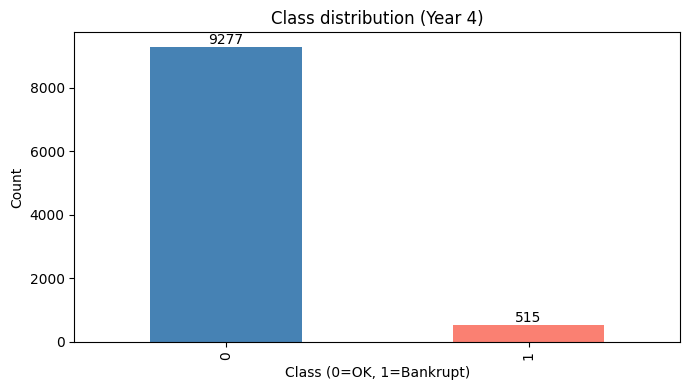

In [38]:
df = X.copy()
df['class'] = y['class']
df = df[df['year'] == 4].drop(columns=['year'])

X = df.drop(columns=['class'])
y = df['class']
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

bankrupt = (y == 1).sum()
not_bankrupt = (y == 0).sum()
missing_cells = X.isnull().sum().sum()
total_cells = X.size

print(f"Shape: {X.shape}")
print(f"Bankrupt: {bankrupt} ({100*bankrupt/len(y):.1f}%)")
print(f"Not bankrupt: {not_bankrupt} ({100*not_bankrupt/len(y):.1f}%)")
print(f"\nMissing values: {missing_cells} ({100*missing_cells/total_cells:.1f}% cells)")

fig, ax = plt.subplots(figsize=(7, 4))
y.value_counts().sort_index().plot.bar(ax=ax, color=['steelblue', 'salmon'])
ax.set_title('Class distribution (Year 4)')
ax.set_xlabel('Class (0=OK, 1=Bankrupt)')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [39]:
pd.set_option('display.float_format', '{:.2f}'.format)

desc = X.describe().T
desc['missing_%'] = (X.isnull().sum() / len(X) * 100).round(1)

print(desc[['mean', 'std', 'min', '50%', 'max', 'missing_%']].to_string())

       mean       std         min    50%         max  missing_%
A1     0.04      0.36      -12.46   0.04       20.48       0.00
A2     0.60      4.59        0.00   0.47      446.91       0.00
A3     0.13      4.56     -445.91   0.20       22.77       0.00
A4     8.14    290.65       -0.05   1.59    27146.00       0.40
A5    64.26  14732.27  -379000.00  -0.06  1030000.00       0.20
A6    -0.06      6.81     -486.82   0.00      322.20       0.00
A7     0.06      0.53      -12.46   0.05       38.62       0.00
A8    19.88    698.70       -1.85   1.09    53209.00       0.20
A9     1.88     17.67       -0.03   1.16     1704.80       0.00
A10    0.39      4.59     -445.91   0.51       12.60       0.00
A11    0.08      0.53      -12.24   0.06       38.62       0.00
A12    0.21     74.24    -6331.80   0.14     3340.90       0.40
A13    0.40     37.97    -1460.60   0.06     2707.70       0.20
A14    0.06      0.53      -12.46   0.05       38.62       0.00
A15 3018.65 102317.01 -1570000.00 906.56

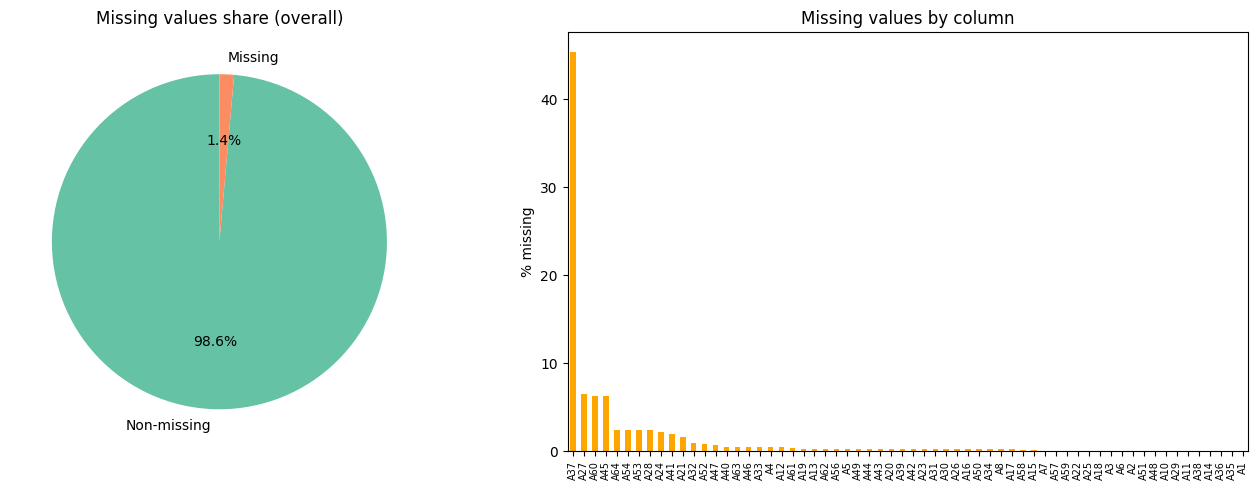

In [40]:
missing_cells = X.isnull().sum().sum()
total_cells = X.size
non_missing_cells = total_cells - missing_cells

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing values overall
axes[0].pie(
    [non_missing_cells, missing_cells],
    labels=['Non-missing', 'Missing'],
    colors=['#66c2a5', '#fc8d62'],
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Missing values share (overall)')

# Missing values per column
missing = (X.isnull().sum() / len(X) * 100).sort_values(ascending=False)
missing = missing[missing > 0]
missing.plot.bar(ax=axes[1], color='orange')
axes[1].set_title('Missing values by column')
axes[1].set_ylabel('% missing')
axes[1].tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.show()

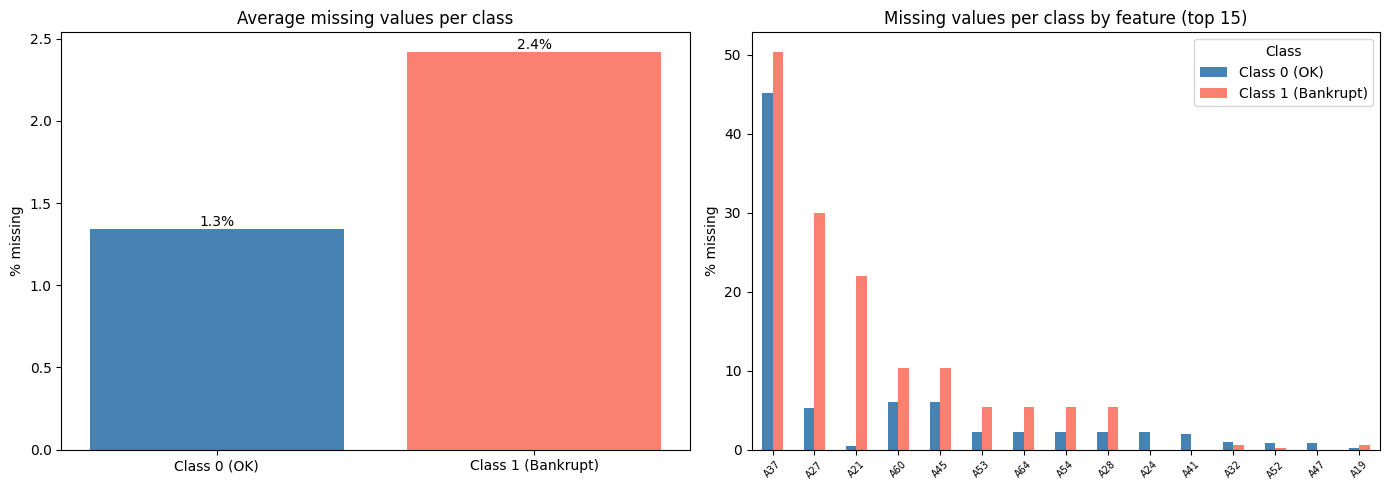

In [41]:
# Percent missing per feature in each class
y_series = y.squeeze()

missing_per_class = (
    (X.isnull().groupby(y_series).mean().T * 100)
    .rename(columns={0: 'Class 0 (OK)', 1: 'Class 1 (Bankrupt)'})
)

missing_summary = pd.DataFrame({
    'Class 0 (OK)': [missing_per_class['Class 0 (OK)'].mean()],
    'Class 1 (Bankrupt)': [missing_per_class['Class 1 (Bankrupt)'].mean()]
}, index=['Average missing % across features'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

left_vals = missing_summary.iloc[0]
left_labels = left_vals.index.tolist()
left_colors = ['steelblue', 'salmon']
axes[0].bar(left_labels, left_vals.values, color=left_colors)
axes[0].set_title('Average missing values per class')
axes[0].set_ylabel('% missing')
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

top_missing_features = (
    missing_per_class.mean(axis=1)
    .sort_values(ascending=False)
    .head(15)
    .index
)
missing_per_class.loc[top_missing_features].plot.bar(
    ax=axes[1],
    color=['steelblue', 'salmon']
 )
axes[1].set_title('Missing values per class by feature (top 15)')
axes[1].set_ylabel('% missing')
axes[1].tick_params(axis='x', labelsize=7, rotation=45)
axes[1].legend(title='Class')

plt.tight_layout()
plt.show()

Usuwamy A37, bo przy 45% braków imputacja medianą stworzyłaby sztuczny rozkład, a informację o płynności pokrywają inne kolumny (A46, A50, A4).

In [42]:
X = X.drop(columns=['A37'])
print("Shape after dropping A37:", X.shape)
print("Remaining missing:", X.isnull().sum().sum())

Shape after dropping A37: (9792, 63)
Remaining missing: 4334


In [43]:
missing_per_row = X.isnull().sum(axis=1)

print("Rows with any missing value:", (missing_per_row > 0).sum(), f"({100*(missing_per_row > 0).mean():.2f}%)")
print()
print("Avg missing features per row:")
print(f"  Class 0 (OK):       {missing_per_row[y==0].mean():.2f}")
print(f"  Class 1 (Bankrupt): {missing_per_row[y==1].mean():.2f}")

Rows with any missing value: 1701 (17.37%)

Avg missing features per row:
  Class 0 (OK):       0.41
  Class 1 (Bankrupt): 1.04


/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_78668/1424315801.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


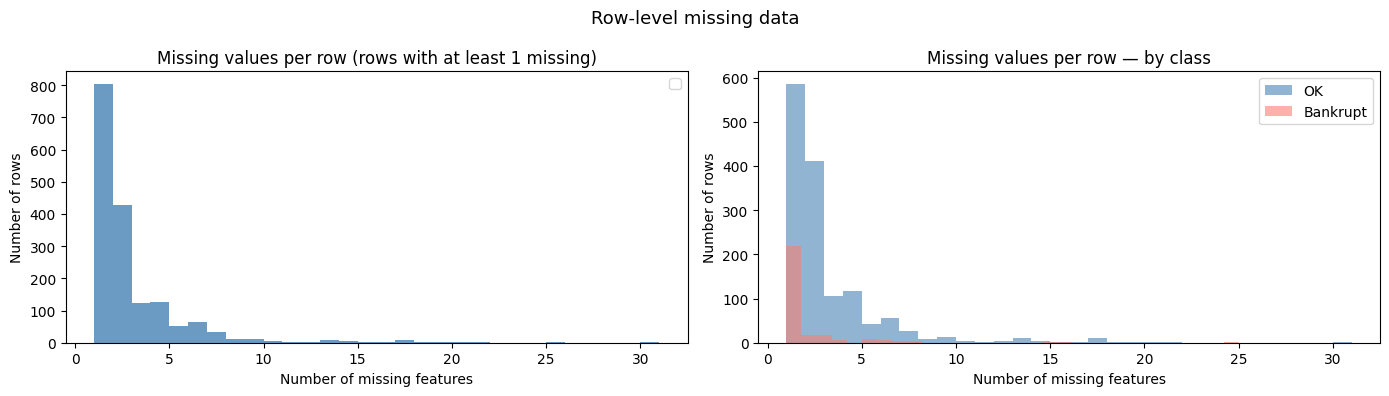

In [44]:
missing_per_row = X.isnull().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(missing_per_row[missing_per_row > 0], bins=30, color='steelblue', alpha=0.8)
axes[0].set_title('Missing values per row (rows with at least 1 missing)')
axes[0].set_xlabel('Number of missing features')
axes[0].set_ylabel('Number of rows')
axes[0].legend()

for cls, label, color in [(0, 'OK', 'steelblue'), (1, 'Bankrupt', 'salmon')]:
    vals = missing_per_row[y == cls]
    vals = vals[vals > 0]
    axes[1].hist(vals, bins=30, alpha=0.6, label=label, color=color)
axes[1].set_title('Missing values per row — by class')
axes[1].set_xlabel('Number of missing features')
axes[1].set_ylabel('Number of rows')
axes[1].legend()

plt.suptitle('Row-level missing data', fontsize=13)
plt.tight_layout()
plt.show()

In [45]:
rows_before = len(X)
bankrupt_before = (y == 1).sum()
ok_before = (y == 0).sum()

mask_complete = X.isnull().sum(axis=1) <= 7
X = X[mask_complete].reset_index(drop=True)
y = y[mask_complete].reset_index(drop=True)

rows_dropped = rows_before - len(X)


print("Dropped rows with more than 7 missing features.")
print(f"Rows before: {rows_before}  -> after: {len(X)}  (dropped: {rows_dropped}, {100*rows_dropped/rows_before:.1f}%)")
print()
print(f"Bankrupt: {bankrupt_before} -> {(y==1).sum()} (dropped: {bankrupt_before - (y==1).sum()})")
print(f"OK:       {ok_before} -> {(y==0).sum()} (dropped: {ok_before - (y==0).sum()})")

Dropped rows with more than 7 missing features.
Rows before: 9792  -> after: 9719  (dropped: 73, 0.7%)

Bankrupt: 515 -> 508 (dropped: 7)
OK:       9277 -> 9211 (dropped: 66)


### Uzupełnianie braków

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

print(f"Train: {X_train.shape[0]} rows, bankrupt: {(y_train==1).sum()} ({100*(y_train==1).mean():.1f}%)")
print(f"Test:  {X_test.shape[0]} rows, bankrupt: {(y_test==1).sum()} ({100*(y_test==1).mean():.1f}%)")

X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

Train: 7775 rows, bankrupt: 406 (5.2%)
Test:  1944 rows, bankrupt: 102 (5.2%)


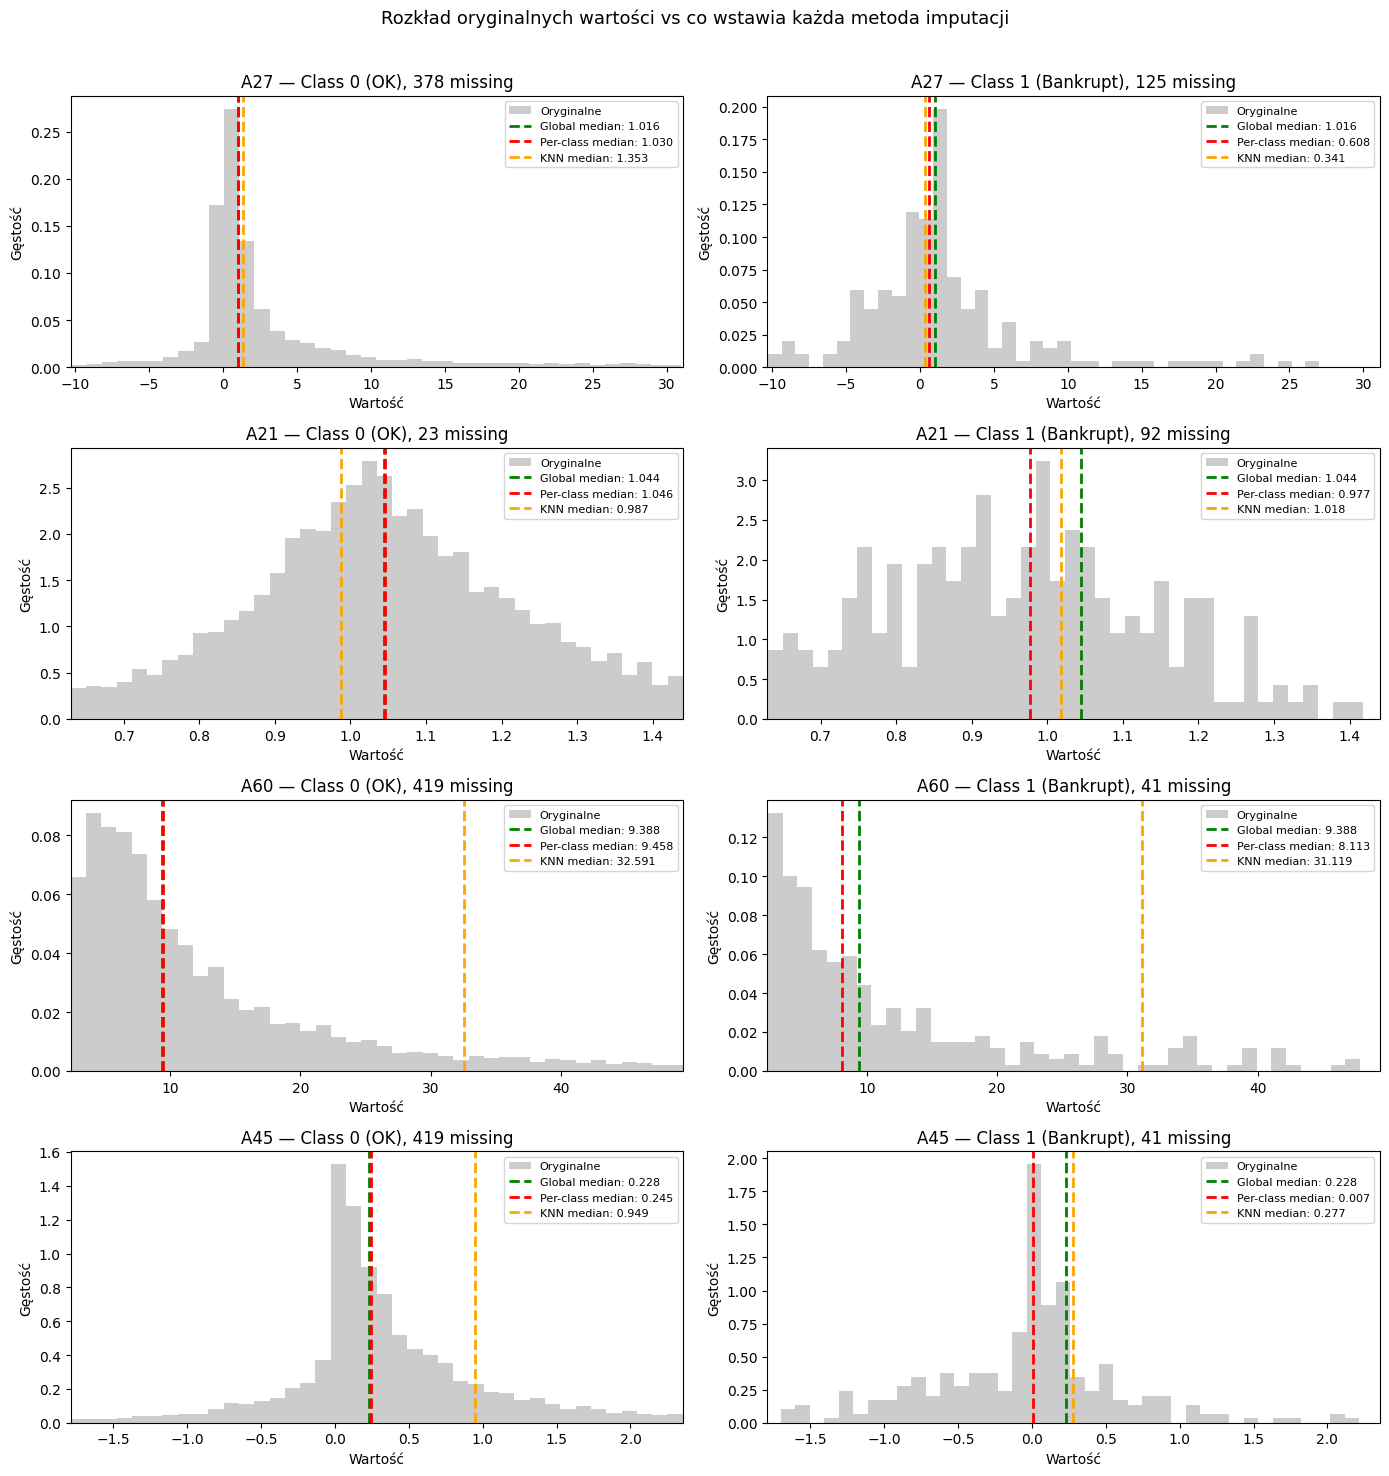

In [ ]:
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

focus_cols = ['A27', 'A21', 'A60', 'A45']

imp_global = SimpleImputer(strategy='median')
X_global = pd.DataFrame(imp_global.fit_transform(X_train), columns=X_train.columns)

X_per_class = X_train.copy()
for col in X_train.columns:
    for cls in [0, 1]:
        mask = pd.Series(y_train.values == cls, index=X_train.index)
        col_median = X_train.loc[mask, col].median()
        X_per_class.loc[mask & X_per_class[col].isna(), col] = col_median

means = X_train.mean()
stds = X_train.std().replace(0, 1)
X_train_scaled = (X_train - means) / stds

imp_knn = KNNImputer(n_neighbors=5)
X_knn_scaled = imp_knn.fit_transform(X_train_scaled)
X_knn = pd.DataFrame(X_knn_scaled * stds.values + means.values, columns=X_train.columns)

fig, axes = plt.subplots(len(focus_cols), 2, figsize=(14, 4 * len(focus_cols)))

for row_idx, col in enumerate(focus_cols):
    missing_mask = X_train[col].isna()

    all_original = X_train.loc[~missing_mask, col]
    lo, hi = all_original.quantile(0.05), all_original.quantile(0.90)

    for cls_idx, (cls, cls_label) in enumerate([(0, 'OK'), (1, 'Bankrupt')]):
        cls_mask = pd.Series(y_train.values == cls, index=X_train.index)
        was_missing = missing_mask & cls_mask

        ax = axes[row_idx, cls_idx]

        original = X_train.loc[~missing_mask & cls_mask, col]
        original_vis = original[(original >= lo) & (original <= hi)]

        ax.hist(original_vis, bins=40, alpha=0.4, label='Oryginalne', color='gray', density=True)

        for val, color, label in [
            (X_global.loc[was_missing, col].median(), 'green', 'Global median'),
            (X_per_class.loc[was_missing, col].median(), 'red', 'Per-class median'),
            (X_knn.loc[was_missing, col].median(), 'orange', 'KNN median'),
        ]:
            if pd.notna(val):
                ax.axvline(val, color=color, linewidth=2, linestyle='--', label=f'{label}: {val:.3f}')

        ax.set_xlim(lo, hi)
        ax.set_title(f'{col} — Class {cls} ({cls_label}), {was_missing.sum()} missing')
        ax.set_xlabel('Wartość')
        ax.set_ylabel('Gęstość')
        ax.legend(fontsize=8)

plt.suptitle('Rozkład oryginalnych wartości vs co wstawia każda metoda imputacji', fontsize=13)
plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.show()

In [48]:
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

global_median = X_train.median()

X_train_imp = X_train.copy()
for col in X_train.columns:
    X_train_imp.loc[X_train_imp[col].isna(), col] = global_median[col]

X_test_imp = X_test.copy()
for col in X_test.columns:
    X_test_imp.loc[X_test_imp[col].isna(), col] = global_median[col]

X_train = X_train_imp
X_test  = X_test_imp

print("Missing in train:", X_train.isnull().sum().sum())
print("Missing in test: ", X_test.isnull().sum().sum())

Missing in train: 0
Missing in test:  0


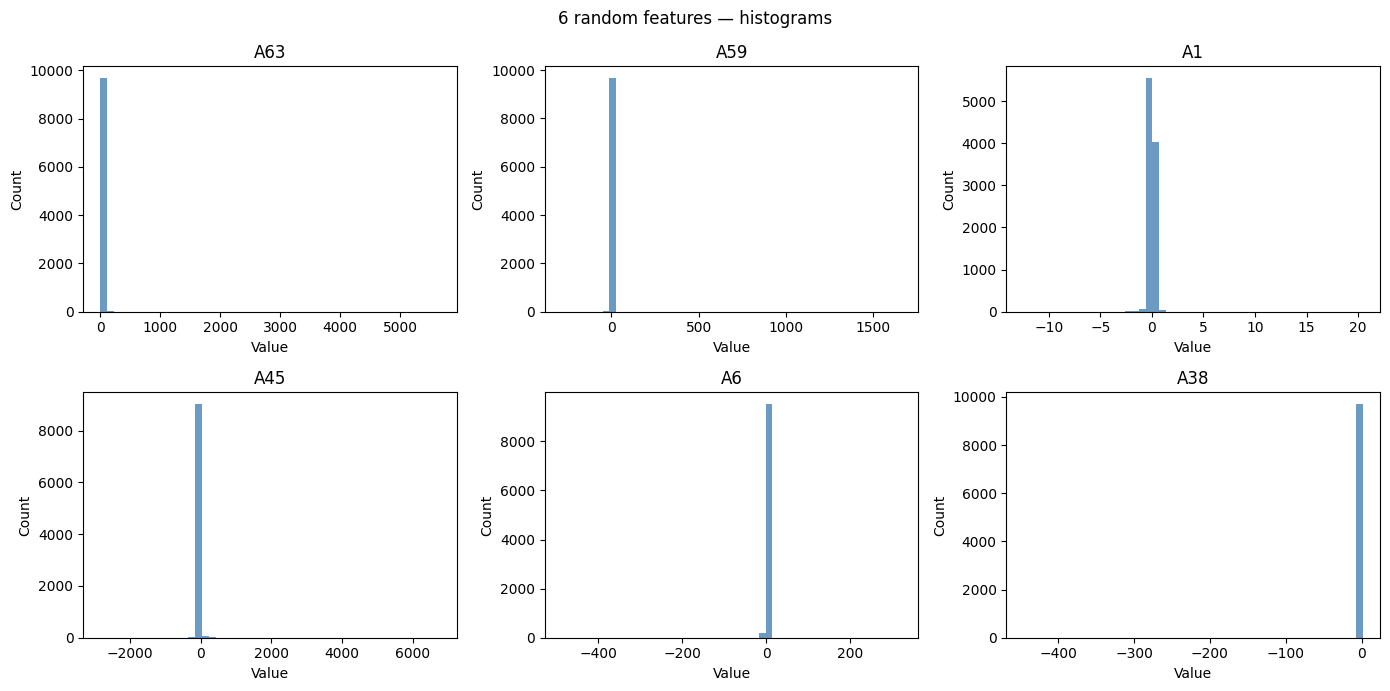

In [49]:
sample_cols = X.columns.to_series().sample(6, random_state=42).tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), sample_cols):
    ax.hist(X[col].dropna(), bins=50, color='steelblue', alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('6 random features — histograms')
plt.tight_layout()
plt.show()

### Analiza i pozbycie się outlierów

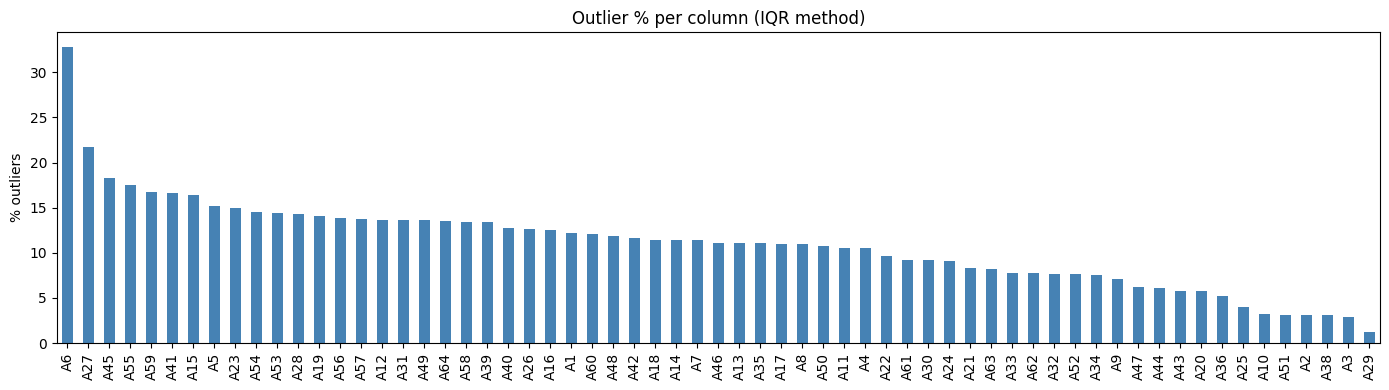

Total outlier cells: 53834 (11.0%)
Rows with at least 1 outlier: 6987 (90%)


In [50]:
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (X_train < Q1 - 1.5 * IQR) | (X_train > Q3 + 1.5 * IQR)
outlier_pct = (outlier_mask.sum() / len(X_train) * 100).sort_values(ascending=False)

plt.figure(figsize=(14, 4))
outlier_pct.plot.bar(color='steelblue')
plt.title('Outlier % per column (IQR method)')
plt.ylabel('% outliers')
plt.tight_layout()
plt.show()

print(f"Total outlier cells: {outlier_mask.sum().sum()} ({100 * outlier_mask.sum().sum() / X_train.size:.1f}%)")
print(f"Rows with at least 1 outlier: {outlier_mask.any(axis=1).sum()} ({100 * outlier_mask.any(axis=1).mean():.0f}%)")

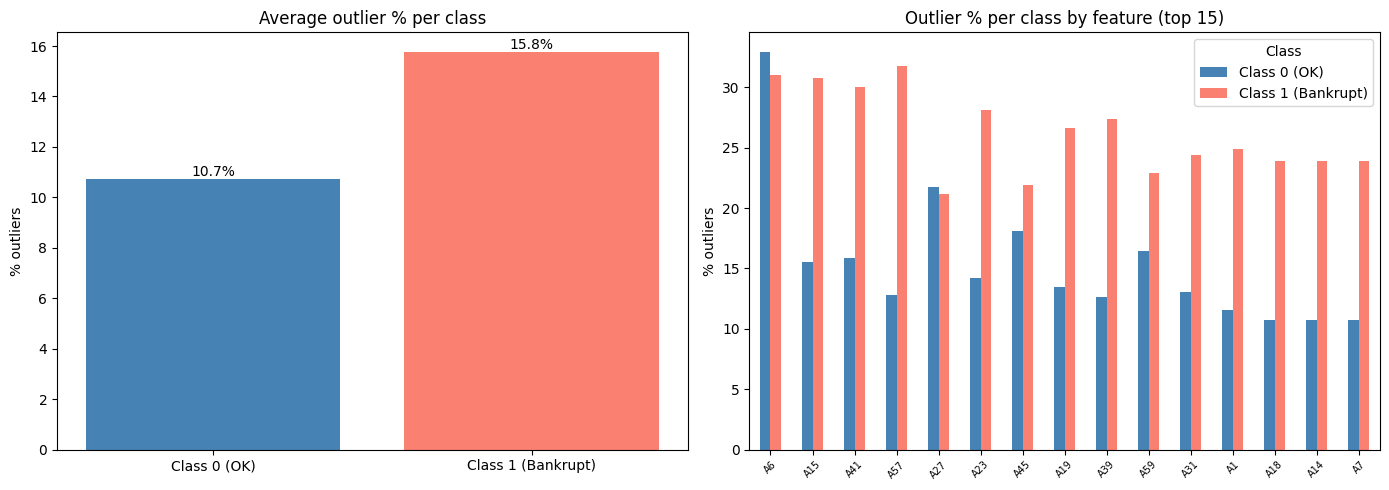

Total outlier cells: 53834 (11.0%)
Rows with at least 1 outlier: 6987 (90%)
Avg outliers per row — OK:       6.76
Avg outliers per row — Bankrupt: 9.93


In [51]:
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (X_train < Q1 - 1.5 * IQR) | (X_train > Q3 + 1.5 * IQR)
outlier_pct = (outlier_mask.sum() / len(X_train) * 100).sort_values(ascending=False)

outlier_per_class = pd.DataFrame({
    'Class 0 (OK)':       outlier_mask[y_train.values == 0].mean() * 100,
    'Class 1 (Bankrupt)': outlier_mask[y_train.values == 1].mean() * 100,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

left_vals = outlier_per_class.mean()
axes[0].bar(left_vals.index.tolist(), left_vals.values, color=['steelblue', 'salmon'])
axes[0].set_title('Average outlier % per class')
axes[0].set_ylabel('% outliers')
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom')

top_outlier_features = (
    outlier_per_class.mean(axis=1)
    .sort_values(ascending=False)
    .head(15)
    .index
)
outlier_per_class.loc[top_outlier_features].plot.bar(
    ax=axes[1],
    color=['steelblue', 'salmon']
)
axes[1].set_title('Outlier % per class by feature (top 15)')
axes[1].set_ylabel('% outliers')
axes[1].tick_params(axis='x', labelsize=7, rotation=45)
axes[1].legend(title='Class')

plt.tight_layout()
plt.show()

print(f"Total outlier cells: {outlier_mask.sum().sum()} ({100 * outlier_mask.sum().sum() / X_train.size:.1f}%)")
print(f"Rows with at least 1 outlier: {outlier_mask.any(axis=1).sum()} ({100 * outlier_mask.any(axis=1).mean():.0f}%)")
print(f"Avg outliers per row — OK:       {outlier_mask[y_train.values == 0].sum(axis=1).mean():.2f}")
print(f"Avg outliers per row — Bankrupt: {outlier_mask[y_train.values == 1].sum(axis=1).mean():.2f}")

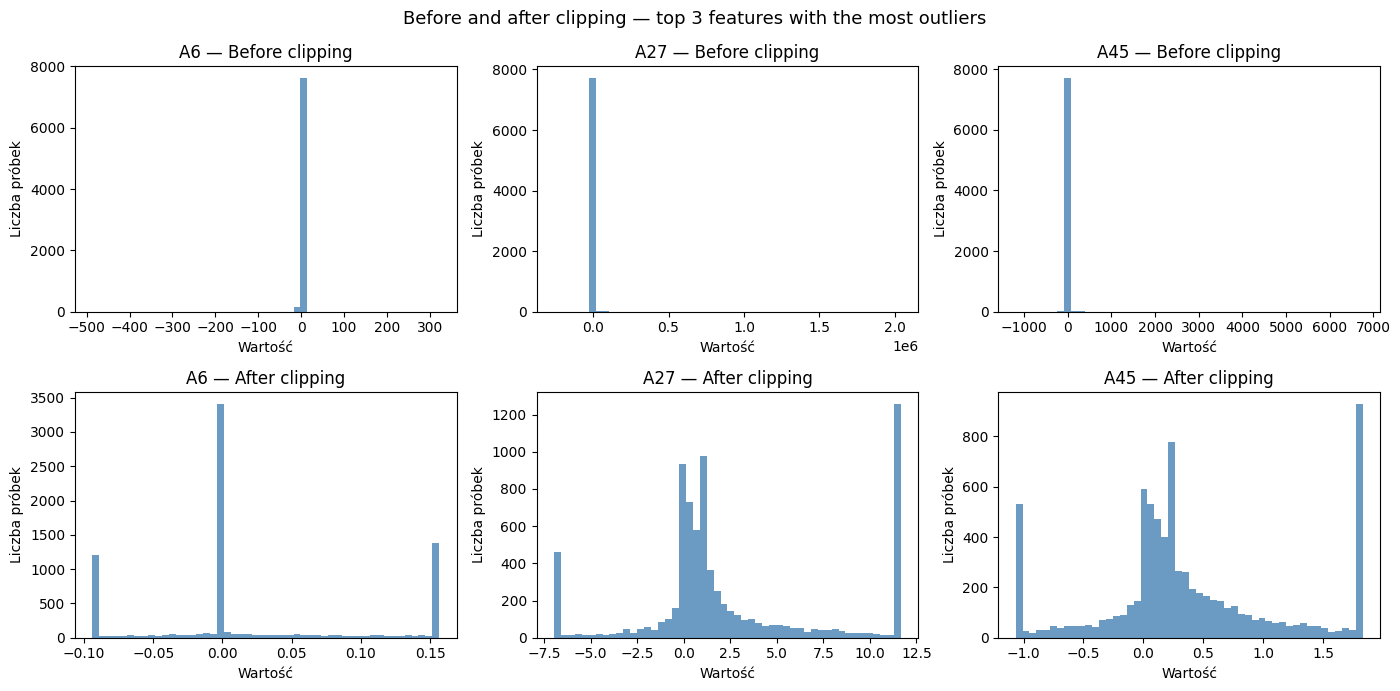

In [52]:
X_train_before_clip = X_train.copy()
X_test_before_clip = X_test.copy()

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

top3_cols = outlier_pct.head(3).index.tolist()

X_train_clipped = X_train.clip(lower=lower, upper=upper, axis=1)
X_test_clipped = X_test.clip(lower=lower, upper=upper, axis=1)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for col_idx, col in enumerate(top3_cols):
    for row_idx, (data, title) in enumerate([
        (X_train[col],         'Before clipping'),
        (X_train_clipped[col], 'After clipping'),
    ]):
        ax = axes[row_idx, col_idx]
        ax.hist(data.dropna(), bins=50, color='steelblue', alpha=0.8)
        ax.set_title(f'{col} — {title}')
        ax.set_xlabel('Wartość')
        ax.set_ylabel('Liczba próbek')

plt.suptitle('Before and after clipping — top 3 features with the most outliers', fontsize=13)
plt.tight_layout()
plt.show()

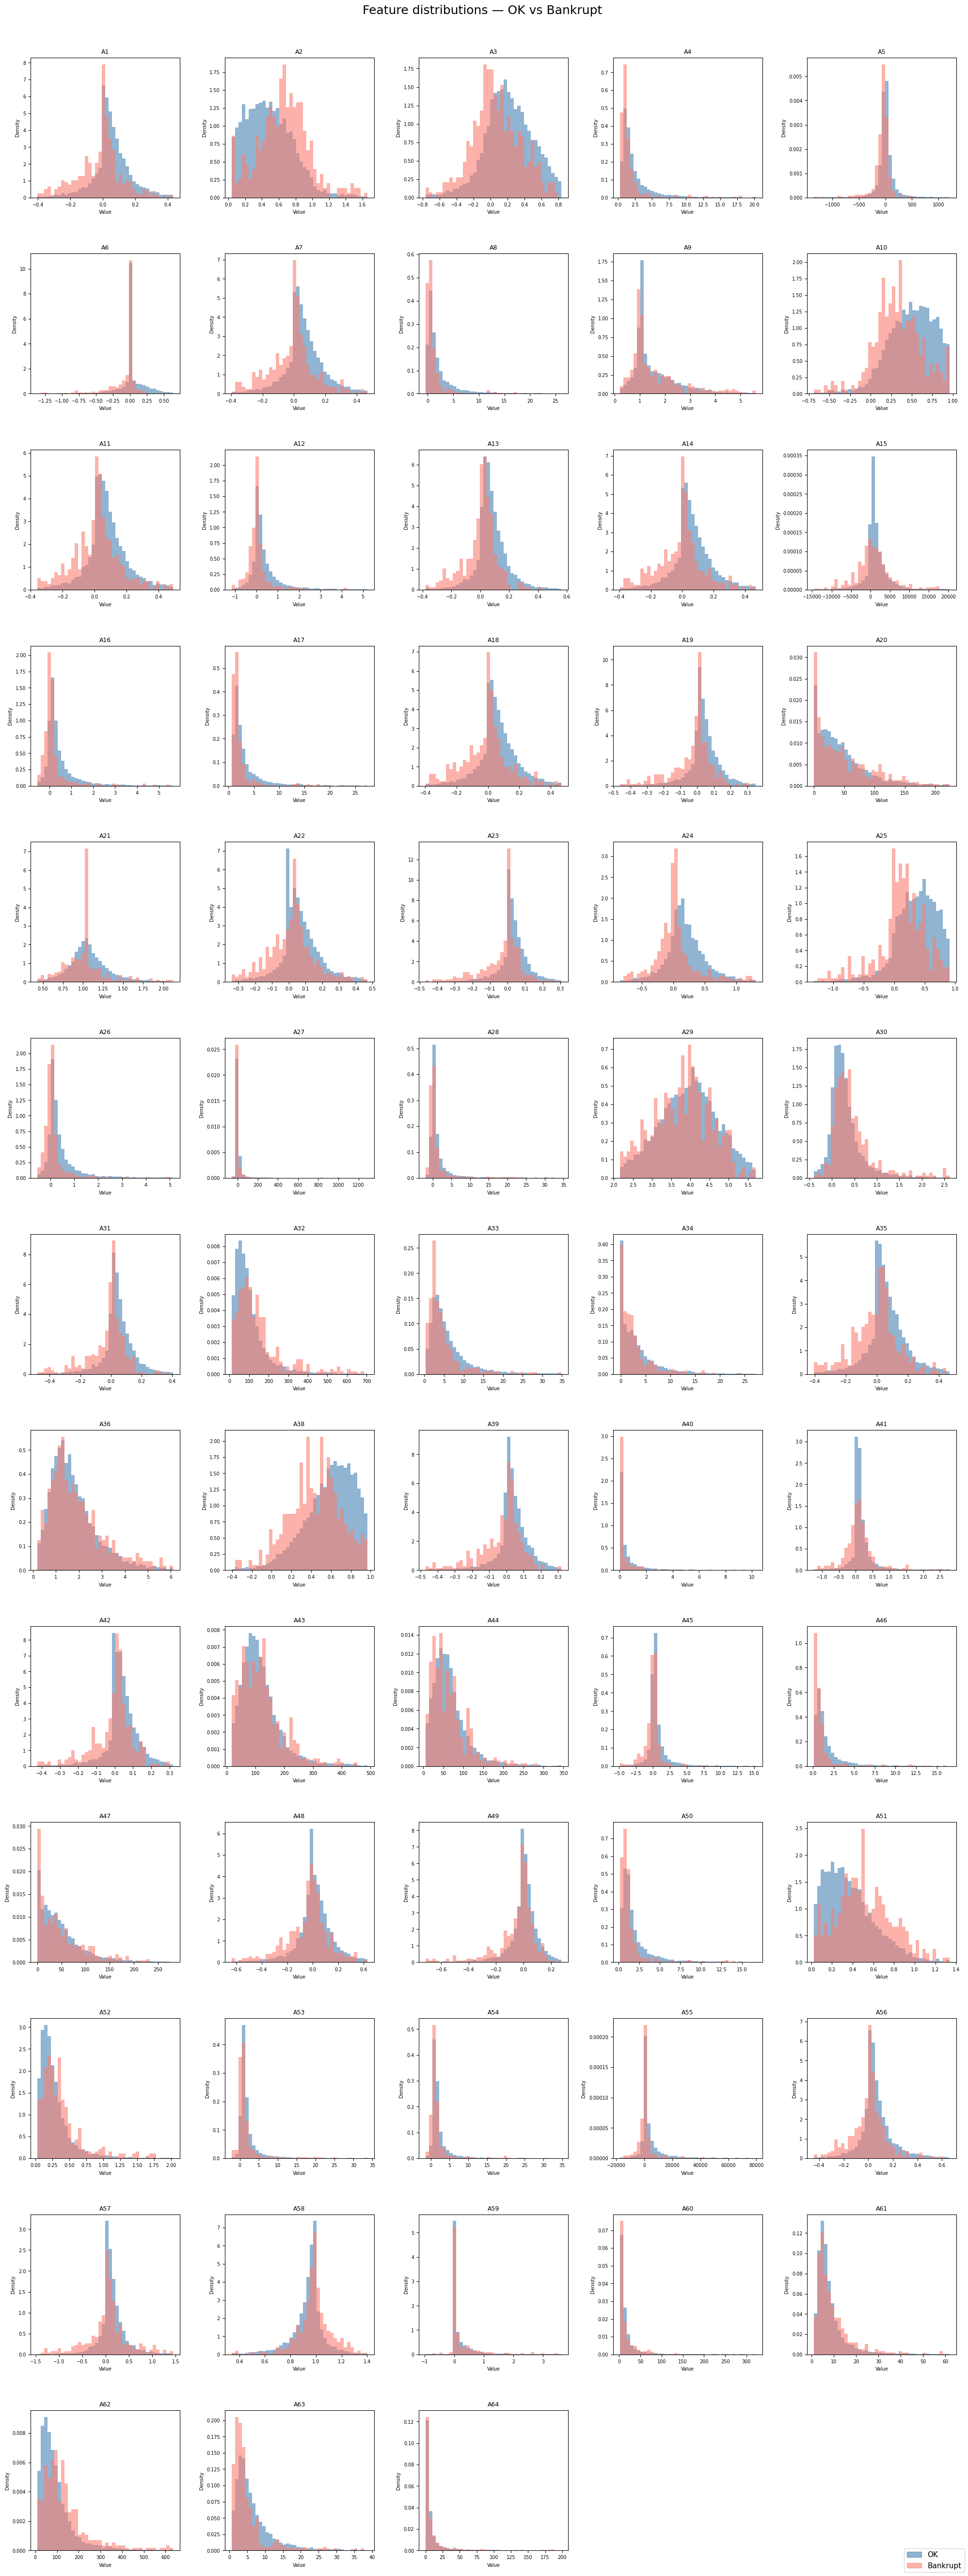

In [53]:
all_cols = X_train.columns.tolist()
n_cols = len(all_cols)
n_rows = (n_cols + 4) // 5

fig, axes = plt.subplots(n_rows, 5, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(all_cols):
    ax = axes[idx]
    vals_ok       = X_train.loc[y_train == 0, col].dropna()
    vals_bankrupt = X_train.loc[y_train == 1, col].dropna()

    lo = X_train[col].quantile(0.02)
    hi = X_train[col].quantile(0.98)

    ax.hist(vals_ok,       bins=40, color='steelblue', alpha=0.6,
            label='OK',       density=True, range=(lo, hi))
    ax.hist(vals_bankrupt, bins=40, color='salmon',    alpha=0.6,
            label='Bankrupt', density=True, range=(lo, hi))
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Value', fontsize=7)
    ax.set_ylabel('Density', fontsize=7)
    ax.tick_params(labelsize=7)


for idx in range(len(all_cols), len(axes)):
    axes[idx].set_visible(False)

handles = [
    plt.Rectangle((0,0),1,1, color='steelblue', alpha=0.6),
    plt.Rectangle((0,0),1,1, color='salmon',    alpha=0.6),
]
fig.legend(handles, ['OK', 'Bankrupt'], loc='lower right', fontsize=11)

plt.suptitle('Feature distributions — OK vs Bankrupt', fontsize=18, y=1.02)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.3, top=0.999)
plt.show()

In [54]:
X_train = X_train_clipped
X_test = X_test_clipped

print("Outlier cells after clipping:", ((X_train < lower) | (X_train > upper)).sum().sum())

Outlier cells after clipping: 0


### Standaryzacja 

In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

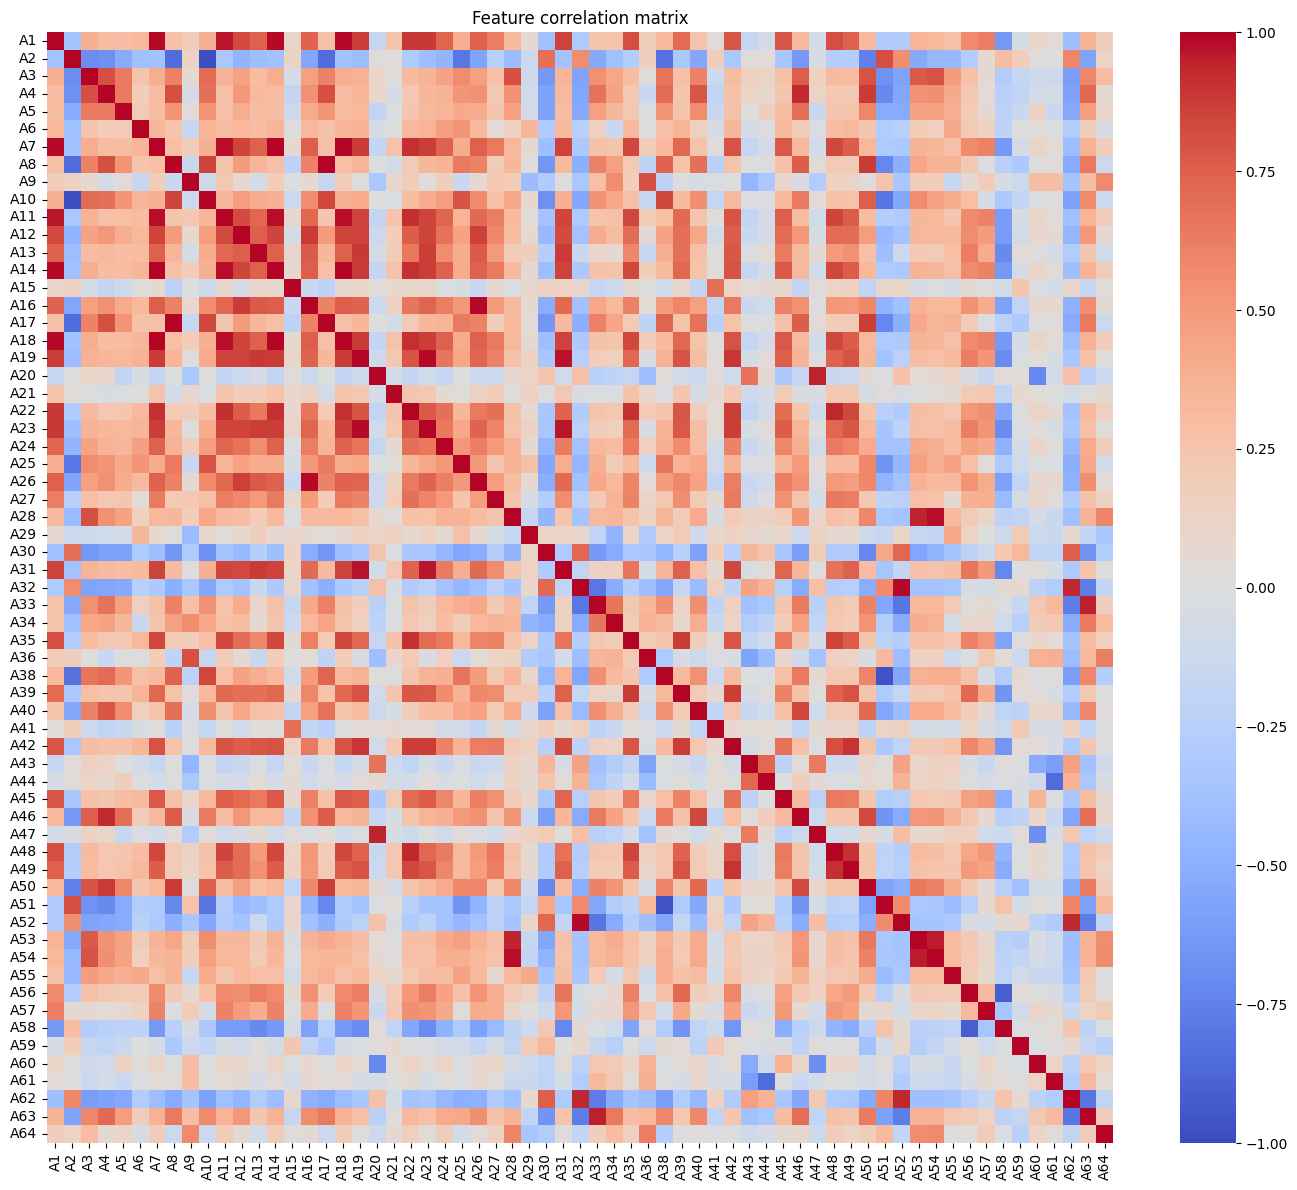

In [56]:
corr = X_train.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True, linewidths=0)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

### PCA i t-SNE

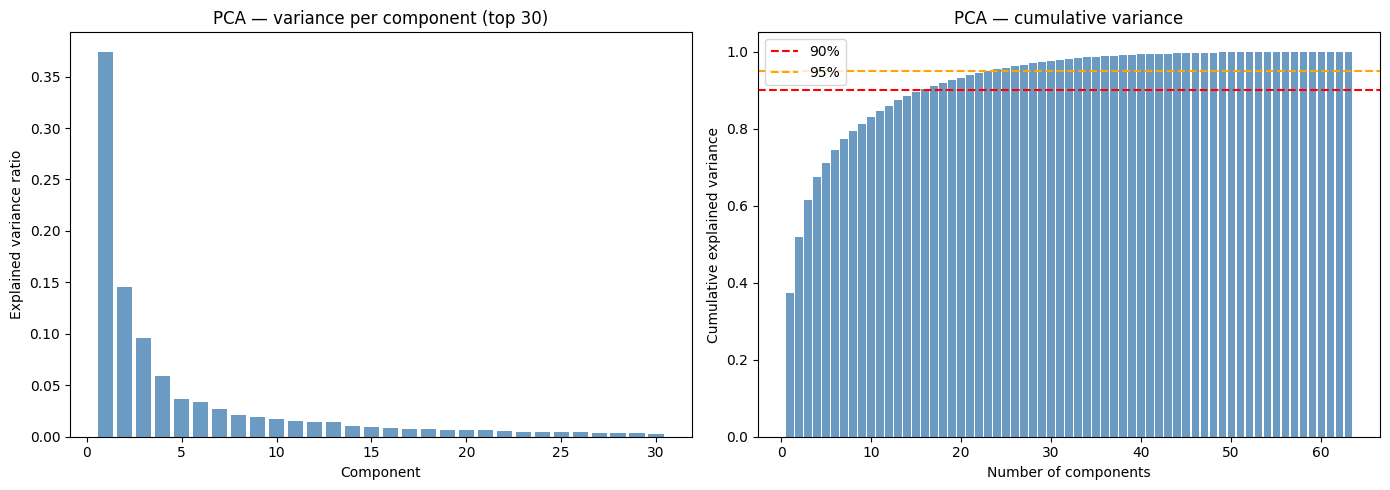

Components for 90%: 16
Components for 95%: 24
First 2 components: 52.0%


In [57]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

cumvar = pca_full.explained_variance_ratio_.cumsum()
var_ratio = pca_full.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 31), var_ratio[:30], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('PCA — variance per component (top 30)')

axes[1].bar(range(1, len(cumvar)+1), cumvar, color='steelblue', alpha=0.8)
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90%')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95%')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('PCA — cumulative variance')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Components for 90%: {(cumvar >= 0.90).argmax() + 1}")
print(f"Components for 95%: {(cumvar >= 0.95).argmax() + 1}")
print(f"First 2 components: {cumvar[1]*100:.1f}%")

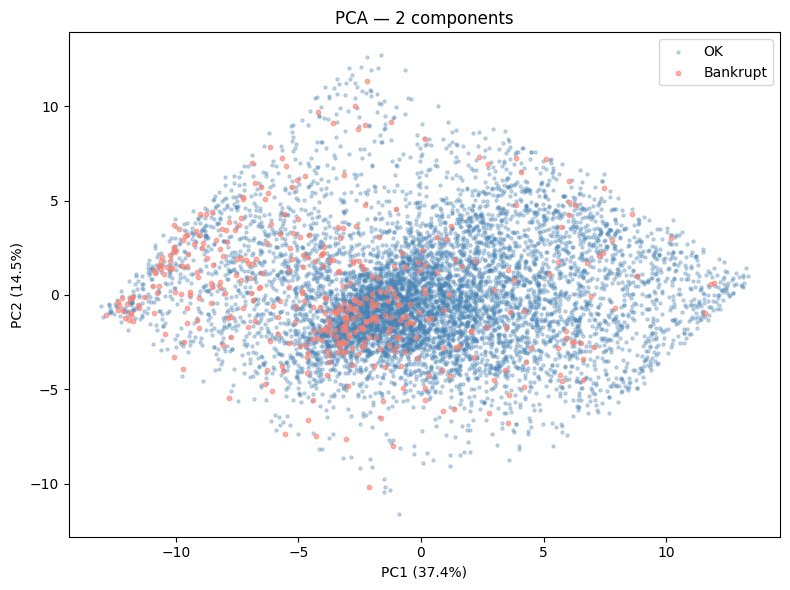

In [58]:
pca2 = PCA(n_components=2)
X_train_pca = pca2.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1], c='steelblue', alpha=0.3, s=5, label='OK')
plt.scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1], c='salmon', alpha=0.6, s=10, label='Bankrupt')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA — 2 components')
plt.legend()
plt.tight_layout()
plt.show()

### t-SNE

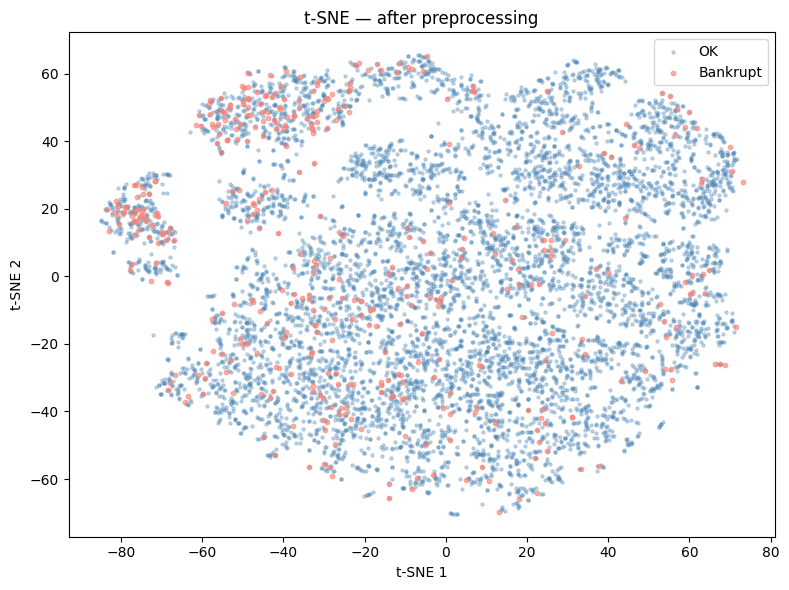

In [59]:
tsne = TSNE(n_components=2, perplexity=30)
X_tsne = tsne.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[y_train == 0, 0], X_tsne[y_train == 0, 1], c='steelblue', alpha=0.3, s=5, label='OK')
plt.scatter(X_tsne[y_train == 1, 0], X_tsne[y_train == 1, 1], c='salmon', alpha=0.6, s=10, label='Bankrupt')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE — after preprocessing')
plt.legend()
plt.tight_layout()
plt.show()

### Modelowanie

In [60]:
def fit_and_eval(model, X_tr_raw, X_te_raw, y_tr, y_te):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  model)
    ])
    pipe.fit(X_tr_raw, y_tr)
    y_pred = pipe.predict(X_te_raw)
    metrics = {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred, zero_division=0),
    }
    return pipe, y_pred, metrics

dt_pipe, y_pred_dt, metrics_dt = fit_and_eval(
    DecisionTreeClassifier(max_depth=5, class_weight='balanced'),
    X_train, X_test, y_train, y_test
)

lr_pipe, y_pred_lr, metrics_lr = fit_and_eval(
    LogisticRegression(C=1, class_weight='balanced', solver='lbfgs', max_iter=2000),
    X_train, X_test, y_train, y_test
)

pd.DataFrame(
    {'Decision Tree': metrics_dt, 'Logistic Regression': metrics_lr}
).T.round(3)

,Accuracy,Precision,Recall
Decision Tree,0.82,0.17,0.64
Logistic Regression,0.74,0.14,0.74


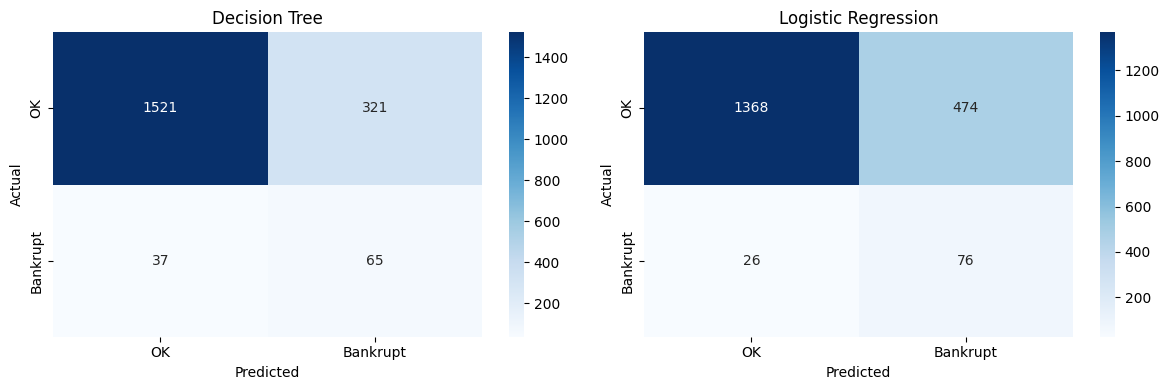

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, name in zip(axes,
                             [y_pred_dt,  y_pred_lr],
                             ['Decision Tree', 'Logistic Regression']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['OK', 'Bankrupt'],
                yticklabels=['OK', 'Bankrupt'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(name)

plt.tight_layout()
plt.show()

Preprocessing variants:   0%|          | 0/6 [00:00<?, ?it/s]


=== Decision Tree — preprocessing ===
                      Accuracy  Precision  Recall
Clipping + Standard       0.82       0.17    0.64
Clipping + MinMax         0.82       0.17    0.64
Clipping + No scaler      0.82       0.17    0.64
No clip + Standard        0.82       0.17    0.64
No clip + MinMax          0.74       0.11    0.58
No clip + No scaler       0.82       0.17    0.64

=== LR — preprocessing ===
                      Accuracy  Precision  Recall
Clipping + Standard       0.74       0.14    0.74
Clipping + MinMax         0.73       0.14    0.76
Clipping + No scaler      0.71       0.12    0.72
No clip + Standard        0.74       0.12    0.66
No clip + MinMax          0.62       0.08    0.57
No clip + No scaler       0.63       0.10    0.77


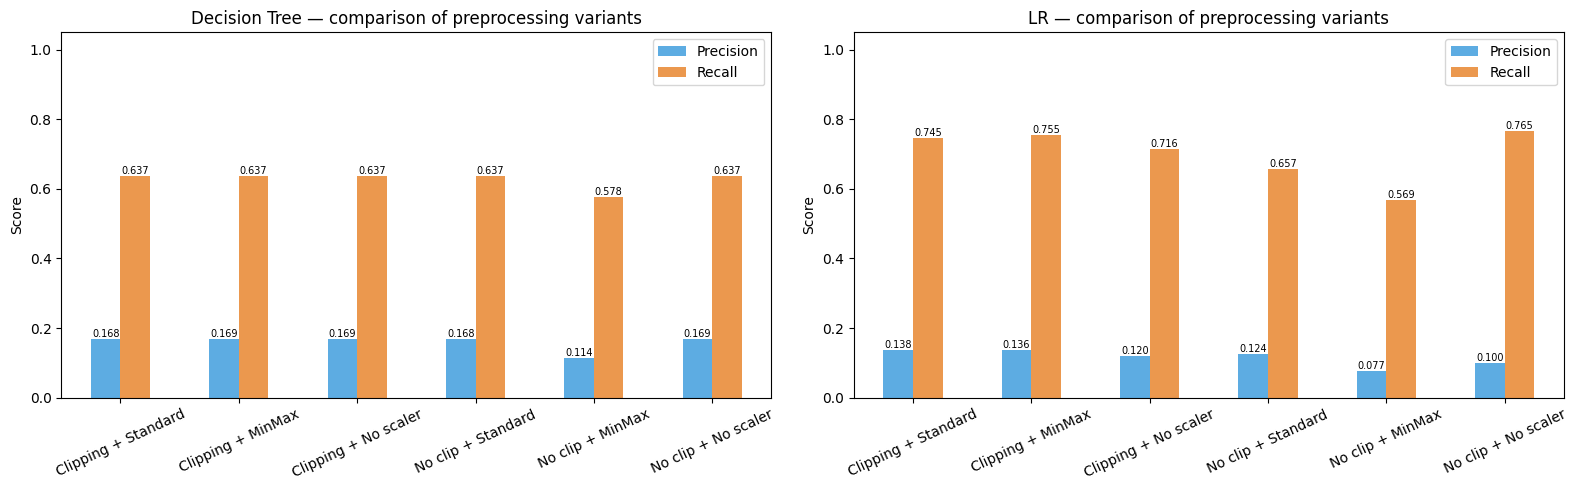

In [62]:
prep_variants = [
    ('Clipping + Standard',  X_train,             X_test,             StandardScaler()),
    ('Clipping + MinMax',    X_train,             X_test,             MinMaxScaler()),
    ('Clipping + No scaler', X_train,             X_test,             FunctionTransformer()),
    ('No clip + Standard',   X_train_before_clip, X_test_before_clip, StandardScaler()),
    ('No clip + MinMax',     X_train_before_clip, X_test_before_clip, MinMaxScaler()),
    ('No clip + No scaler',  X_train_before_clip, X_test_before_clip, FunctionTransformer()),
]

models_cfg = [
    ('Decision Tree', DecisionTreeClassifier(max_depth=5, class_weight='balanced')),
    ('LR',            LogisticRegression(C=1, class_weight='balanced', solver='lbfgs',
                                         max_iter=2000)),
]

results_prep = {'Decision Tree': {}, 'LR': {}}

for prep_name, X_tr, X_te, scaler in tqdm(prep_variants, desc="Preprocessing variants"):
    for model_name, model_obj in models_cfg:
        pipe = Pipeline([('scaler', scaler), ('model', clone(model_obj))])
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', ConvergenceWarning)
            pipe.fit(X_tr, y_train)
        y_pred = pipe.predict(X_te)
        results_prep[model_name][prep_name] = {
            'Accuracy':  accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall':    recall_score(y_test, y_pred, zero_division=0),
        }

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, model_name in zip(axes, ['Decision Tree', 'LR']):
    df = pd.DataFrame(results_prep[model_name]).T.round(3)
    print(f"\n=== {model_name} — preprocessing ===")
    print(df.to_string())
    df[['Precision', 'Recall']].plot.bar(
        ax=ax, color=['#3498db', '#e67e22'], alpha=0.8)
    ax.set_title(f'{model_name} — comparison of preprocessing variants')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=25)
    ax.legend()
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

Imputation variants:   0%|          | 0/3 [00:00<?, ?it/s]


=== Decision Tree — imputation ===
                  Accuracy  Precision  Recall
Median global         0.82       0.17    0.64
Median per class      0.83       0.17    0.60
KNN                   0.70       0.11    0.67

=== LR — imputation ===
                  Accuracy  Precision  Recall
Median global         0.74       0.14    0.74
Median per class      0.75       0.14    0.73
KNN                   0.75       0.14    0.73


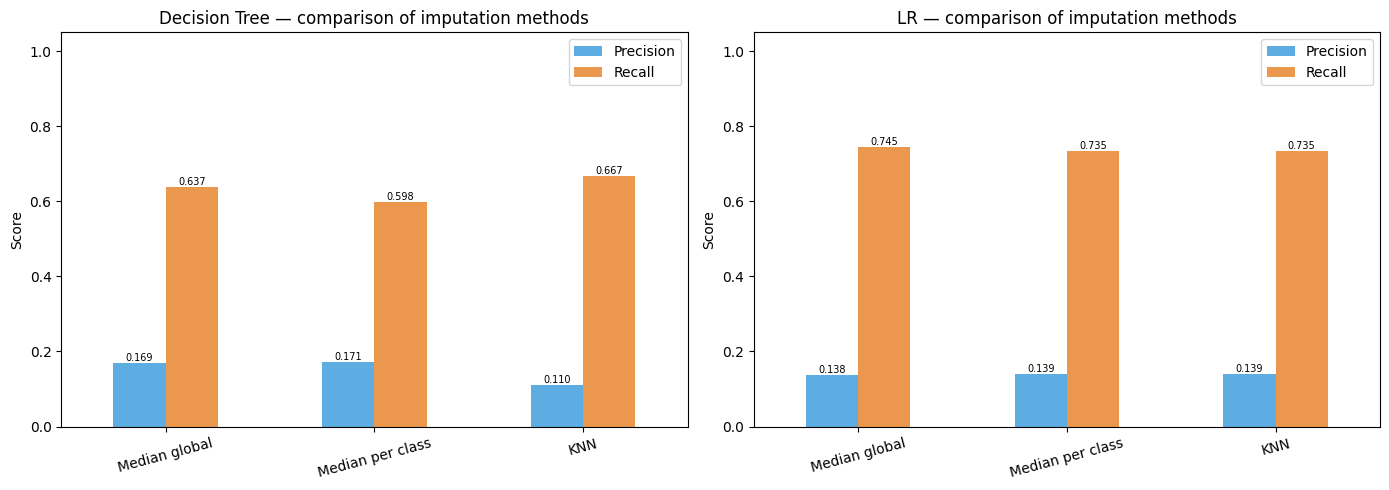

In [63]:
def impute_per_class(X_tr, X_te, y_tr):
    X_tr = X_tr.copy().reset_index(drop=True)
    X_te = X_te.copy().reset_index(drop=True)
    y_tr = y_tr.reset_index(drop=True)
    global_med = X_tr.median()
    class_medians = {}
    for cls in [0, 1]:
        mask = pd.Series(y_tr.values == cls, index=X_tr.index)
        class_medians[cls] = X_tr.loc[mask].median()
    for cls in [0, 1]:
        mask_tr = pd.Series(y_tr.values == cls, index=X_tr.index)
        for col in X_tr.columns:
            fill = class_medians[cls][col] if pd.notna(class_medians[cls][col]) else global_med[col]
            X_tr.loc[mask_tr & X_tr[col].isna(), col] = fill
    for col in X_te.columns:
        X_te.loc[X_te[col].isna(), col] = global_med[col]
    return X_tr, X_te

imp_global = SimpleImputer(strategy='median')
X_tr_global = pd.DataFrame(imp_global.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_te_global = pd.DataFrame(imp_global.transform(X_test_raw),      columns=X_test_raw.columns)

X_tr_perclass, X_te_perclass = impute_per_class(X_train_raw, X_test_raw, y_train)

_knn_scaler = StandardScaler()
_X_train_raw_scaled = _knn_scaler.fit_transform(X_train_raw)
_X_test_raw_scaled  = _knn_scaler.transform(X_test_raw)

imp_knn = KNNImputer(n_neighbors=5)
_X_tr_knn_scaled = imp_knn.fit_transform(_X_train_raw_scaled)
_X_te_knn_scaled = imp_knn.transform(_X_test_raw_scaled)

X_tr_knn = pd.DataFrame(_knn_scaler.inverse_transform(_X_tr_knn_scaled), columns=X_train_raw.columns)
X_te_knn = pd.DataFrame(_knn_scaler.inverse_transform(_X_te_knn_scaled), columns=X_test_raw.columns)

imputation_variants = [
    ('Median global',    X_tr_global,   X_te_global),
    ('Median per class', X_tr_perclass, X_te_perclass),
    ('KNN',              X_tr_knn,      X_te_knn),
]

models_cfg = [
    ('Decision Tree', DecisionTreeClassifier(max_depth=5, class_weight='balanced')),
    ('LR',            LogisticRegression(C=1, class_weight='balanced', solver='lbfgs', max_iter=2000)),
]

results_imp = {'Decision Tree': {}, 'LR': {}}

for imp_name, X_tr, X_te in tqdm(imputation_variants, desc="Imputation variants"):
    Q1_ = X_tr.quantile(0.25); Q3_ = X_tr.quantile(0.75); IQR_ = Q3_ - Q1_
    X_tr_c = X_tr.clip(lower=Q1_ - 1.5*IQR_, upper=Q3_ + 1.5*IQR_, axis=1)
    X_te_c = X_te.clip(lower=Q1_ - 1.5*IQR_, upper=Q3_ + 1.5*IQR_, axis=1)

    for model_name, model_obj in models_cfg:
        pipe = Pipeline([('scaler', StandardScaler()), ('model', clone(model_obj))])
        pipe.fit(X_tr_c, y_train)
        y_pred = pipe.predict(X_te_c)
        results_imp[model_name][imp_name] = {
            'Accuracy':  accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall':    recall_score(y_test, y_pred, zero_division=0),
        }

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model_name in zip(axes, ['Decision Tree', 'LR']):
    df = pd.DataFrame(results_imp[model_name]).T.round(3)
    print(f"\n=== {model_name} — imputation ===")
    print(df.to_string())
    df[['Precision', 'Recall']].plot.bar(
        ax=ax, color=['#3498db', '#e67e22'], alpha=0.8)
    ax.set_title(f'{model_name} — comparison of imputation methods')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=15)
    ax.legend()
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

PCA variants:   0%|          | 0/4 [00:00<?, ?it/s]


=== Decision Tree — PCA ===
                   Accuracy  Precision  Recall
No PCA                 0.82       0.17    0.64
PCA 90% (16 comp)      0.69       0.10    0.64
PCA 95% (24 comp)      0.67       0.10    0.66
PCA 2 comp             0.73       0.11    0.61

=== LR — PCA ===
                   Accuracy  Precision  Recall
No PCA                 0.74       0.14    0.74
PCA 90% (16 comp)      0.69       0.10    0.66
PCA 95% (24 comp)      0.70       0.12    0.71
PCA 2 comp             0.65       0.10    0.72


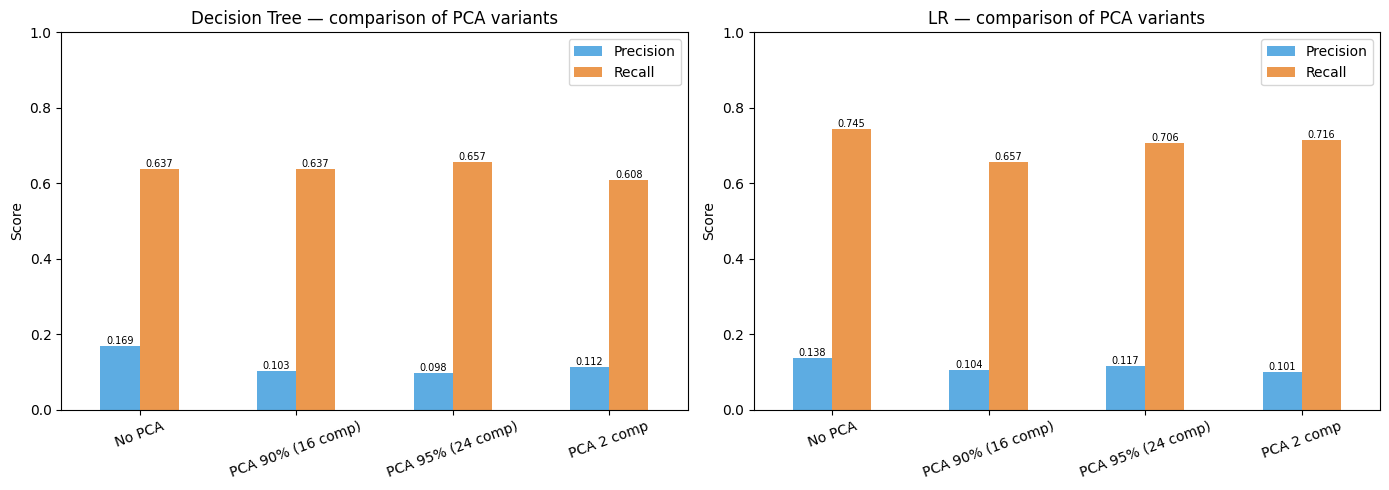

In [64]:
n_90 = (pca_full.explained_variance_ratio_.cumsum() >= 0.90).argmax() + 1
n_95 = (pca_full.explained_variance_ratio_.cumsum() >= 0.95).argmax() + 1

pca_90 = PCA(n_components=n_90).fit(X_train_scaled)
pca_95 = PCA(n_components=n_95).fit(X_train_scaled)
pca_2  = PCA(n_components=2).fit(X_train_scaled)

pca_variants = [
    ('No PCA',                  X_train_scaled,                   X_test_scaled),
    (f'PCA 90% ({n_90} comp)',  pca_90.transform(X_train_scaled), pca_90.transform(X_test_scaled)),
    (f'PCA 95% ({n_95} comp)',  pca_95.transform(X_train_scaled), pca_95.transform(X_test_scaled)),
    ('PCA 2 comp',              pca_2.transform(X_train_scaled),  pca_2.transform(X_test_scaled)),
]

models_cfg = [
    ('Decision Tree', DecisionTreeClassifier(max_depth=5, class_weight='balanced')),
    ('LR',            LogisticRegression(C=1, class_weight='balanced', solver='lbfgs', max_iter=2000)),
]

results_pca = {'Decision Tree': {}, 'LR': {}}

for pca_name, X_tr, X_te in tqdm(pca_variants, desc="PCA variants"):
    for model_name, model_obj in models_cfg:
        clone(model_obj).fit(X_tr, y_train)
        m = clone(model_obj)
        m.fit(X_tr, y_train)
        y_pred = m.predict(X_te)
        results_pca[model_name][pca_name] = {
            'Accuracy':  accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall':    recall_score(y_test, y_pred, zero_division=0),
        }

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model_name in zip(axes, ['Decision Tree', 'LR']):
    df = pd.DataFrame(results_pca[model_name]).T.round(3)
    print(f"\n=== {model_name} — PCA ===")
    print(df.to_string())
    df[['Precision', 'Recall']].plot.bar(
        ax=ax, color=['#3498db', '#e67e22'], alpha=0.8)
    ax.set_title(f'{model_name} — comparison of PCA variants')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=20)
    ax.legend()
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()